✅ 2D Asset saved: ../../../assets/53_cov_2d.png


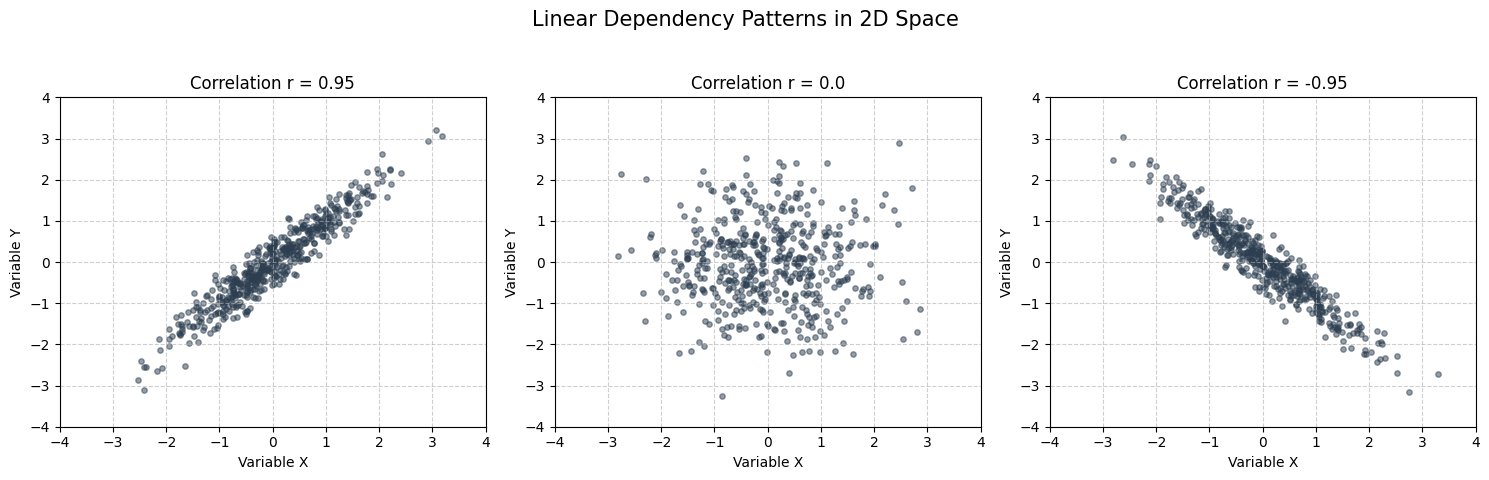

✅ 3D Asset saved: ../../../assets/53_cov_3d.png


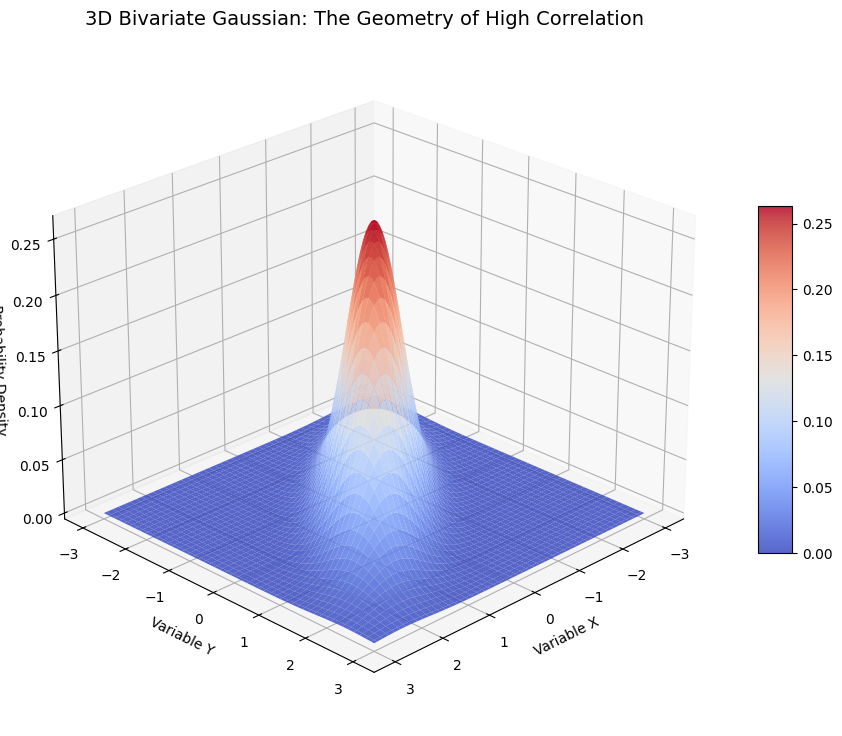

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import os

def run_covariance_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Generate Correlated Data
    def generate_correlated_data(r, n=500):
        mean = [0, 0]
        cov = [[1, r], [r, 1]] # Variance = 1, Covariance = r
        return np.random.multivariate_normal(mean, cov, n)

    # --- 📸 ASSET 1: 2D CORRELATION SPECTRUM (53_cov_2d.png) ---
    correlations = [0.95, 0.0, -0.95]
    fig1, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, r in enumerate(correlations):
        data = generate_correlated_data(r)
        axes[i].scatter(data[:, 0], data[:, 1], alpha=0.5, s=15, color='#2c3e50')
        axes[i].set_title(f"Correlation r = {r}", fontsize=12)
        axes[i].set_xlabel("Variable X"); axes[i].set_ylabel("Variable Y")
        axes[i].grid(True, linestyle='--', alpha=0.6)
        axes[i].set_xlim(-4, 4); axes[i].set_ylim(-4, 4)

    plt.suptitle("Linear Dependency Patterns in 2D Space", fontsize=15)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(asset_path, '53_cov_2d.png'), dpi=300)
    print(f"✅ 2D Asset saved: {asset_path}/53_cov_2d.png")
    plt.show()

    # --- 📸 ASSET 2: 3D BIVARIATE PDF SURFACE (53_cov_3d.png) ---
    fig2 = plt.figure(figsize=(12, 9))
    ax3d = fig2.add_subplot(111, projection='3d')
    
    # Create grid for the surface
    x = np.linspace(-3, 3, 100)
    y = np.linspace(-3, 3, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    # Define a high-correlation bivariate normal distribution
    rv = multivariate_normal([0, 0], [[1, 0.8], [0.8, 1]])
    Z = rv.pdf(pos)

    surf = ax3d.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.85, edgecolor='none')
    
    ax3d.set_title("3D Bivariate Gaussian: The Geometry of High Correlation", fontsize=14)
    ax3d.set_xlabel("Variable X"); ax3d.set_ylabel("Variable Y")
    ax3d.set_zlabel("Probability Density")
    fig2.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    # Adjust view to see the 'ridge' clearly
    ax3d.view_init(elev=25, azim=45)

    plt.savefig(os.path.join(asset_path, '53_cov_3d.png'), dpi=300)
    print(f"✅ 3D Asset saved: {asset_path}/53_cov_3d.png")
    plt.show()

if __name__ == "__main__":
    run_covariance_master()